# CIFAR-10 Baseline CNN

- **Project objective:** Train a baseline CNN on CIFAR-10 using separate training, validation, and locked test partitions.
- **Dataset requirement:** Place `train.npy`, `trainLabels.csv`, `test.npy`, and `sampleSubmission.csv` in `datasets/cifar-10/`; raw data is intentionally excluded from Git.
- **Main libraries:** TensorFlow/Keras, pandas, NumPy, scikit-learn, Matplotlib, and Seaborn.
- **How to run:** Use Python 3.11, start Jupyter from the repository root, and run the cells in order; training runs for 25 epochs.
- **Verified result:** Test accuracy 0.7292 and macro F1 0.7304, reproduced with a fresh 25-epoch training run.
- **Important limitation:** This is a compact baseline trained on CPU, so accuracy is below the improved CNN.

## Import libraries and set random seeds

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import json
import random
import time
import warnings
import importlib.metadata as importlib_metadata
from pathlib import Path

if not hasattr(importlib_metadata, "packages_distributions"):
    importlib_metadata.packages_distributions = lambda: {}

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

print("Libraries imported and random seeds set.")

Libraries imported and random seeds set.


## Check TensorFlow device

In [2]:
device_name = "GPU" if tf.config.list_physical_devices("GPU") else "CPU"
print("TensorFlow version:", tf.__version__)
print("Available device:", device_name)

TensorFlow version: 2.19.0
Available device: CPU


## Locate the local data

The local Kaggle files are used directly. `train.npy` contains many consecutive NumPy image records instead of one large NumPy array.

In [3]:
working_directory = Path.cwd()
if working_directory.name == "CNN":
    notebook_directory = working_directory
elif (working_directory / "CNN").is_dir():
    notebook_directory = working_directory / "CNN"
else:
    raise FileNotFoundError("Run this notebook from the repository root or CNN directory.")

project_root = notebook_directory.parent
dataset_directory = project_root / "datasets" / "cifar-10"
results_directory = notebook_directory / "results"
models_directory = notebook_directory / "models"
results_directory.mkdir(exist_ok=True)
models_directory.mkdir(exist_ok=True)

required_files = ["train.npy", "trainLabels.csv", "test.npy", "sampleSubmission.csv"]
missing_files = [name for name in required_files if not (dataset_directory / name).is_file()]
if missing_files:
    raise FileNotFoundError(
        f"Missing CIFAR-10 files: {missing_files}. Place them in "
        f"'{dataset_directory}' and rerun the notebook."
    )

for name in required_files:
    size_mb = (dataset_directory / name).stat().st_size / (1024 ** 2)
    print(f"{name}: {size_mb:.2f} MB")

train.npy: 152.59 MB
trainLabels.csv: 0.56 MB
test.npy: 915.53 MB
sampleSubmission.csv: 3.04 MB


## Load the concatenated NumPy records

In [4]:
def open_concatenated_npy(path):
    """Open a file containing many consecutive np.save records as a memory-mapped view."""
    with path.open("rb") as handle:
        first_image = np.load(handle, allow_pickle=False)
        first_record_end = handle.tell()
        second_record_start = handle.tell()
        second_image = np.load(handle, allow_pickle=False)
        second_record_end = handle.tell()

    assert first_image.shape == (32, 32, 3)
    assert first_image.dtype == np.uint8
    assert second_image.shape == first_image.shape
    assert second_image.dtype == first_image.dtype

    record_size = first_record_end
    assert second_record_end - second_record_start == record_size
    record_count, remainder = divmod(path.stat().st_size, record_size)
    assert remainder == 0

    header_size = record_size - first_image.nbytes
    record_dtype = np.dtype([
        ("header", f"V{header_size}"),
        ("image", (first_image.dtype, first_image.shape)),
    ])
    records = np.memmap(path, dtype=record_dtype, mode="r", shape=(record_count,))

    for index in [0, record_count // 2, record_count - 1]:
        assert bytes(records["header"][index])[:6] == b"\x93NUMPY"

    return records["image"], records


all_images, image_records = open_concatenated_npy(dataset_directory / "train.npy")
labels_frame = pd.read_csv(dataset_directory / "trainLabels.csv")

print("Local training image shape:", all_images.shape)
print("Image dtype:", all_images.dtype)
print("Pixel range:", int(all_images.min()), "to", int(all_images.max()))
print("Label table shape:", labels_frame.shape)

Local training image shape: (50000, 32, 32, 3)
Image dtype: uint8


Pixel range: 0 to 255
Label table shape: (50000, 2)


## Verify labels and class order

In [5]:
assert list(labels_frame.columns) == ["id", "label"]
assert np.array_equal(labels_frame["id"].to_numpy(), np.arange(1, len(labels_frame) + 1))
assert len(all_images) == len(labels_frame) == 50000
assert all_images.shape[1:] == (32, 32, 3)
assert all_images.dtype == np.uint8
assert set(labels_frame["label"].unique()) == set(CLASS_NAMES)

label_to_number = {name: index for index, name in enumerate(CLASS_NAMES)}
all_labels = labels_frame["label"].map(label_to_number).to_numpy(dtype=np.int64)

assert all_labels.shape == (50000,)
assert all_labels.min() == 0 and all_labels.max() == 9
assert len(CLASS_NAMES) == 10

class_counts = labels_frame["label"].value_counts().reindex(CLASS_NAMES)
display(class_counts.to_frame("samples"))
print("CIFAR-10 label order verified:", CLASS_NAMES)

,samples
label,
airplane,5000
automobile,5000
bird,5000
cat,5000
deer,5000
dog,5000
frog,5000
horse,5000
ship,5000


CIFAR-10 label order verified: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Create training, validation, and test sets

The Kaggle test file has no real labels, so a stratified 80/10/10 split is created from the labeled data. The locked test set is not used during training.

In [6]:
all_indices = np.arange(len(all_labels))
trainval_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.10,
    random_state=SEED,
    stratify=all_labels,
)
train_indices, validation_indices = train_test_split(
    trainval_indices,
    test_size=1 / 9,
    random_state=SEED,
    stratify=all_labels[trainval_indices],
)

x_train = np.ascontiguousarray(all_images[train_indices])
y_train = all_labels[train_indices]
x_validation = np.ascontiguousarray(all_images[validation_indices])
y_validation = all_labels[validation_indices]
x_test = np.ascontiguousarray(all_images[test_indices])
y_test = all_labels[test_indices]

assert x_train.shape == (40000, 32, 32, 3)
assert x_validation.shape == (5000, 32, 32, 3)
assert x_test.shape == (5000, 32, 32, 3)
assert set(train_indices).isdisjoint(validation_indices)
assert set(train_indices).isdisjoint(test_indices)
assert set(validation_indices).isdisjoint(test_indices)

print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_validation.shape, y_validation.shape)
print("Locked test set:", x_test.shape, y_test.shape)
print("Samples per class in test set:", np.bincount(y_test).tolist())

Training set: (40000, 32, 32, 3) (40000,)
Validation set: (5000, 32, 32, 3) (5000,)
Locked test set: (5000, 32, 32, 3) (5000,)
Samples per class in test set: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500]


## Normalize images with an efficient data pipeline

In [7]:
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE


def normalize_image(image, label):
    return tf.cast(image, tf.float32) / 255.0, label


def make_dataset(images, labels_array, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((images, labels_array))
    if training:
        dataset = dataset.shuffle(
            min(len(images), 10000), seed=SEED, reshuffle_each_iteration=True
        )
    dataset = dataset.map(
        normalize_image, num_parallel_calls=AUTOTUNE, deterministic=True
    )
    dataset = dataset.batch(BATCH_SIZE)
    if not training:
        dataset = dataset.cache()
    return dataset.prefetch(AUTOTUNE)


train_dataset = make_dataset(x_train, y_train, training=True)
validation_dataset = make_dataset(x_validation, y_validation)
test_dataset = make_dataset(x_test, y_test)

image_batch, label_batch = next(iter(train_dataset))
print("Normalized batch shape:", image_batch.shape)
print("Normalized pixel range:", float(tf.reduce_min(image_batch)), "to", float(tf.reduce_max(image_batch)))

Normalized batch shape: (128, 32, 32, 3)
Normalized pixel range: 0.0 to 1.0


## Display balanced sample images

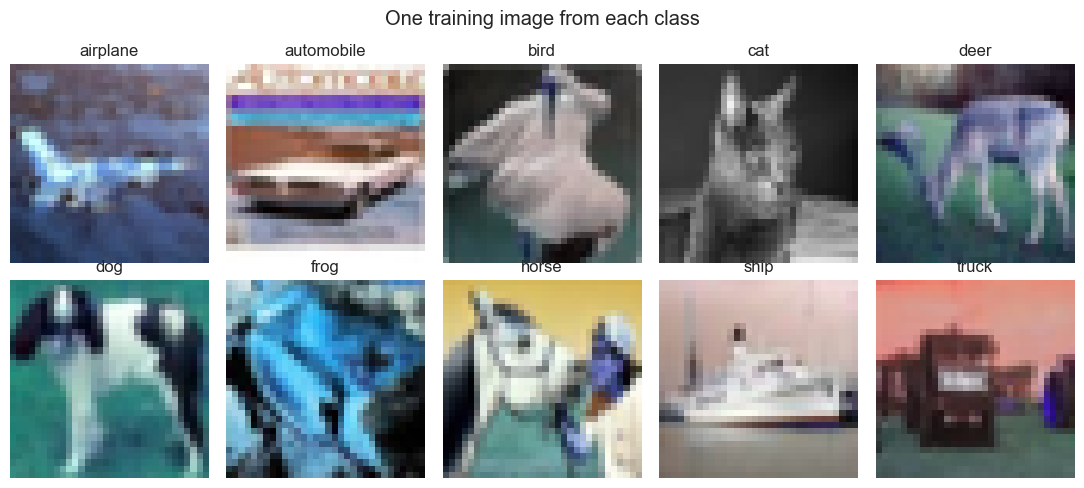

In [8]:
sample_indices = []
for class_number in range(10):
    sample_indices.append(np.flatnonzero(y_train == class_number)[0])

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for axis, index, class_name in zip(axes.ravel(), sample_indices, CLASS_NAMES):
    axis.imshow(x_train[index])
    axis.set_title(class_name)
    axis.axis("off")
plt.suptitle("One training image from each class")
plt.tight_layout()
plt.show()

## Build the baseline CNN

In [9]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

baseline_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
], name="baseline_cifar10_cnn")

assert baseline_model.output_shape[-1] == 10
print("Baseline CNN created.")

Baseline CNN created.


## Model summary

In [10]:
baseline_model.summary()

Model: "baseline_cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## Compile the model

Labels stay as integers, so sparse categorical cross-entropy is the correct multiclass loss.

In [11]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)
print("Output units: 10, activation: softmax, loss: sparse categorical cross-entropy")

Output units: 10, activation: softmax, loss: sparse categorical cross-entropy


## Train the baseline

On CPU, this fixed 25-epoch run is expected to take about 10 to 25 minutes. Only the validation split is used to monitor generalization.

In [12]:
start_time = time.perf_counter()
history = baseline_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    verbose=2,
)
training_time = time.perf_counter() - start_time

print("Epochs trained:", len(history.history["loss"]))
print("Training time (seconds):", round(training_time, 2))

Epoch 1/25


313/313 - 37s - 117ms/step - accuracy: 0.4308 - loss: 1.5656 - val_accuracy: 0.5482 - val_loss: 1.2764


Epoch 2/25


313/313 - 34s - 108ms/step - accuracy: 0.5840 - loss: 1.1736 - val_accuracy: 0.6236 - val_loss: 1.0713


Epoch 3/25


...

Epoch 24/25


313/313 - 29s - 94ms/step - accuracy: 0.9717 - loss: 0.0813 - val_accuracy: 0.7268 - val_loss: 1.5856


Epoch 25/25


313/313 - 31s - 99ms/step - accuracy: 0.9790 - loss: 0.0639 - val_accuracy: 0.7296 - val_loss: 1.7281


Epochs trained: 25
Training time (seconds): 799.81


## Training curves

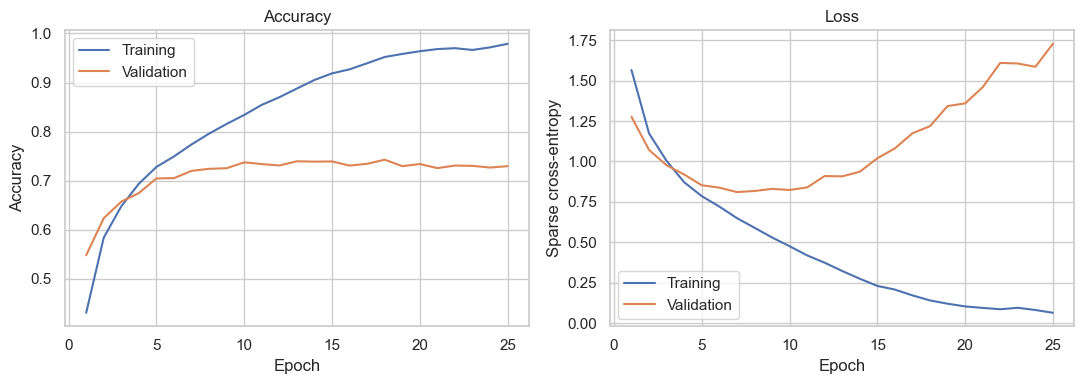

In [13]:
epochs = np.arange(1, len(history.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, history.history["accuracy"], label="Training")
axes[0].plot(epochs, history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs, history.history["loss"], label="Training")
axes[1].plot(epochs, history.history["val_loss"], label="Validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Sparse cross-entropy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Final test evaluation

The architecture and epoch count are fixed before this first evaluation of the locked test set.

In [14]:
test_loss, test_accuracy = baseline_model.evaluate(test_dataset, verbose=0)
test_probabilities = baseline_model.predict(test_dataset, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)
test_confidences = np.max(test_probabilities, axis=1)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test, test_predictions, average="macro", zero_division=0
)

print("BASELINE TEST LOSS:", f"{test_loss:.4f}")
print("BASELINE TEST ACCURACY:", f"{test_accuracy:.4f}")
print("BASELINE MACRO PRECISION:", f"{macro_precision:.4f}")
print("BASELINE MACRO RECALL:", f"{macro_recall:.4f}")
print("BASELINE MACRO F1:", f"{macro_f1:.4f}")

BASELINE TEST LOSS: 1.6915
BASELINE TEST ACCURACY: 0.7292
BASELINE MACRO PRECISION: 0.7387
BASELINE MACRO RECALL: 0.7292
BASELINE MACRO F1: 0.7304


## Classification report

In [15]:
print(classification_report(
    y_test,
    test_predictions,
    target_names=CLASS_NAMES,
    digits=4,
))

              precision    recall  f1-score   support

    airplane     0.8326    0.7260    0.7756       500
  automobile     0.8862    0.8100    0.8464       500
        bird     0.7318    0.5240    0.6107       500
         cat     0.5236    0.5980    0.5584       500
        deer     0.6763    0.7020    0.6889       500
         dog     0.5642    0.6680    0.6117       500
        frog     0.8256    0.7480    0.7849       500
       horse     0.7255    0.7980    0.7600       500
        ship     0.8680    0.8680    0.8680       500
       truck     0.7535    0.8500    0.7989       500

    accuracy                         0.7292      5000
   macro avg     0.7387    0.7292    0.7304      5000
weighted avg     0.7387    0.7292    0.7304      5000



## Confusion matrix

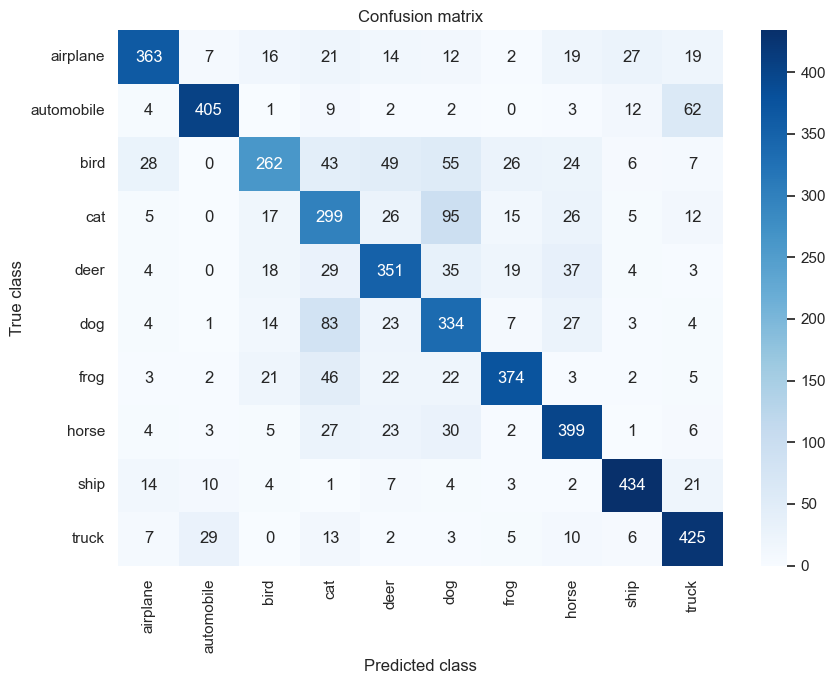

In [16]:
matrix = confusion_matrix(y_test, test_predictions)
plt.figure(figsize=(9, 7))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title("Confusion matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

## Sample predictions

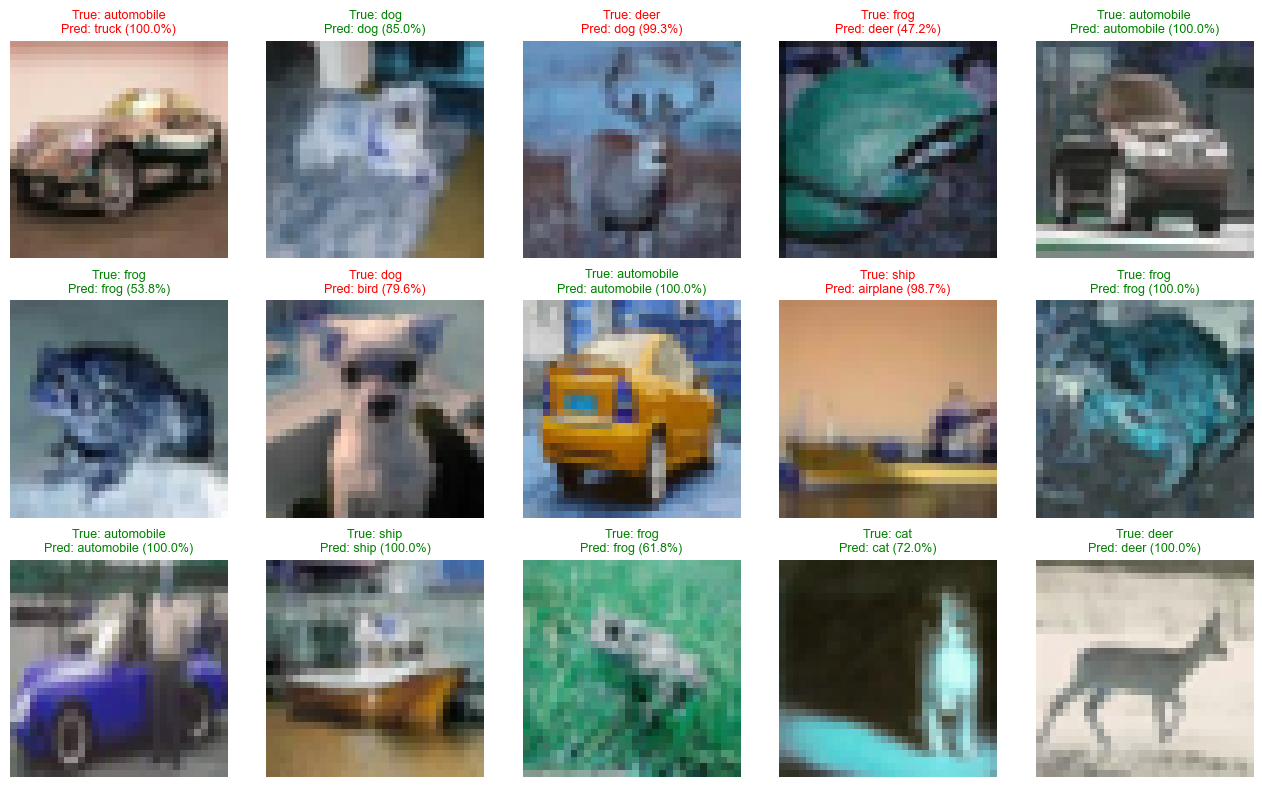

In [17]:
rng = np.random.default_rng(SEED)
display_indices = rng.choice(len(x_test), size=15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(13, 8))
for axis, index in zip(axes.ravel(), display_indices):
    true_number = y_test[index]
    predicted_number = test_predictions[index]
    confidence = test_confidences[index]
    correct = true_number == predicted_number
    axis.imshow(x_test[index])
    axis.set_title(
        f"True: {CLASS_NAMES[true_number]}\n"
        f"Pred: {CLASS_NAMES[predicted_number]} ({confidence:.1%})",
        color="green" if correct else "red",
        fontsize=9,
    )
    axis.axis("off")
plt.tight_layout()
plt.show()

## Save the real baseline metrics

In [18]:
baseline_metrics = {
    "model_name": "Baseline CNN",
    "architecture": "Three convolution blocks and a small dense head",
    "parameter_count": int(baseline_model.count_params()),
    "best_validation_accuracy": float(max(history.history["val_accuracy"])),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "epochs_trained": int(len(history.history["loss"])),
    "training_time_seconds": float(training_time),
}

with (results_directory / "baseline_metrics.json").open("w", encoding="utf-8") as file:
    json.dump(baseline_metrics, file, indent=2)

print("Saved: results/baseline_metrics.json")
display(pd.DataFrame([baseline_metrics]).round(4))

Saved: results/baseline_metrics.json


,model_name,architecture,parameter_count,best_validation_accuracy,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,epochs_trained,training_time_seconds
0,Baseline CNN,Three convolution blocks and a small dense head,356810,0.7428,1.6915,0.7292,0.7387,0.7292,0.7304,25,799.8134


## Conclusion

The baseline uses the correct local data, integer labels, softmax output, and sparse multiclass loss. Validation data comes only from the training partition, and the locked test set is evaluated after training is complete.